#  House Price Prediction Using Machine Learning

## Objective
The objective of this project is to build a machine learning model capable of predicting residential house prices using the Ames Housing Dataset.

---

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Analyze Missing Values
5. Handle Missing Data
6. Perform Feature Engineering
7. Encode Categorical Features
8. Train Machine Learning Models
9. Evaluate Performance
10. Generate Predictions
11. Create Kaggle Submission File

---

## Machine Learning Algorithms
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost

---

## Evaluation Metric
RMSE (Root Mean Squared Error)

#  Step 1 — Import Libraries

In this step we import all required Python libraries.

These libraries help us perform:
- Data processing
- Data visualization
- Feature engineering
- Machine learning
- Model evaluation

In [ ]:
! pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost

# Exploratory Data Analysis (EDA)

Before training machine learning models,
we first understand the dataset.

EDA helps us:
- Understand feature distributions
- Detect missing values
- Analyze correlations
- Identify important features
- Detect outliers

In [32]:
# =========================================================
# LOAD ORIGINAL DATASET
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("data/train.csv")

test_df = pd.read_csv("data/test.csv")

In [33]:
# Dataset dimensions

print("Train Shape:", train_df.shape)

print("Test Shape:", test_df.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


# Step 3 — Preview Dataset

We display the first few rows of the dataset to understand:
- Feature names
- Data structure
- Data types
- Values

In [34]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [35]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [25]:
# Statistical summary

train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,HouseAge,TotalSF,TotalBathrooms
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,12.024057,54.732192,2567.048630,2.210616
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,0.399449,30.202904,821.714421,0.785399
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,10.460271,16.000000,334.000000,1.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,11.775105,26.000000,2009.500000,2.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,12.001512,53.000000,2474.000000,2.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,12.273736,72.000000,3004.000000,2.500000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,13.534474,154.000000,11752.000000,6.000000


# Step 5 — Analyze Missing Values

Real-world datasets usually contain missing values.

We identify:
- Columns with missing values
- Number of missing entries
- Features requiring preprocessing

In [36]:
# =========================================================
# MISSING VALUES
# =========================================================

missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

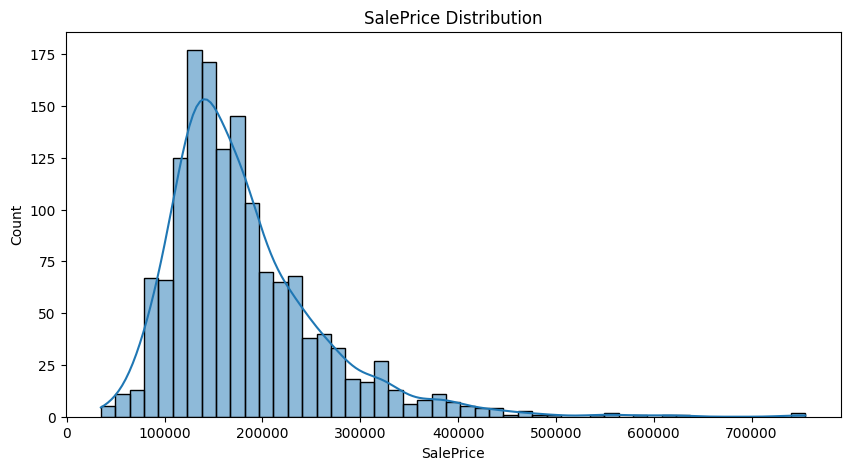

In [37]:
# =========================================================
# TARGET VARIABLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["SalePrice"],
    kde=True
)

plt.title("SalePrice Distribution")

plt.show()

#  Missing Value Handling

The Ames Housing dataset contains several missing values.

These missing values occur because:
- Some houses do not contain specific features
- Real-world datasets are naturally incomplete

Examples:
- No pool
- No fence
- No garage
- No basement

Handling missing values is extremely important because:
- Machine learning models cannot train with NaN values
- Missing values reduce model performance
- Proper preprocessing improves RMSE score

---

## Missing Value Strategy

### Categorical Features
Replace missing values with:
```python
"None"
```

because absence of a feature is meaningful information.

### Numerical Features
Replace missing values using:
```python
Median
```

because median is robust against outliers.

In [50]:
# =========================================================
# DISPLAY MISSING VALUES
# =========================================================

missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageFinish      81
GarageYrBlt       81
GarageType        81
GarageQual        81
GarageCond        81
GarageAge         81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

#  Handle Special Categorical Features

The following features represent optional house components:
- Pool
- Fence
- Garage
- Basement
- Alley access

Missing values in these columns mean:
```python
Feature Not Available
```

Therefore we replace missing values with:
```python
"None"
```

In [51]:
# =========================================================
# FILL SPECIAL CATEGORICAL FEATURES
# =========================================================

special_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",

    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",

    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond",

    "MasVnrType"
]

for col in special_cols:

    if col in train_df.columns:

        train_df[col] = train_df[col].fillna("None")

    if col in test_df.columns:

        test_df[col] = test_df[col].fillna("None")

#  Handle Numerical Features

Numerical columns contain missing values such as:
- LotFrontage
- GarageYrBlt
- MasVnrArea

We replace missing values using:
```python
Median
```

Median is preferred because:
- Less sensitive to outliers
- Better for skewed distributions
- Common in Kaggle competitions

In [52]:
# =========================================================
# FILL NUMERICAL FEATURES
# =========================================================

num_cols = train_df.select_dtypes(
    include=np.number
).columns

for col in num_cols:

    train_df[col].fillna(
        train_df[col].median(),
        inplace=True
    )

    if col in test_df.columns:

        test_df[col].fillna(
            test_df[col].median(),
            inplace=True
        )

# 🔠 Handle Remaining Categorical Features

Some categorical features may still contain missing values.

We replace remaining missing values using:
```python
Mode
```

Mode represents:
- Most frequent category
- Most common value

In [53]:
# =========================================================
# FILL REMAINING CATEGORICAL FEATURES
# =========================================================

cat_cols = train_df.select_dtypes(
    include="object"
).columns

for col in cat_cols:

    train_df[col].fillna(
        train_df[col].mode()[0],
        inplace=True
    )

    if col in test_df.columns:

        test_df[col].fillna(
            test_df[col].mode()[0],
            inplace=True
        )

# ✅ Verify Missing Values

After preprocessing,
we verify that:
- No missing values remain
- Dataset is ready for feature engineering and model training

In [54]:
# =========================================================
# VERIFY MISSING VALUES
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 430
Test Missing Values: 423


In [55]:
# =========================================================
# REMAINING MISSING VALUES
# =========================================================

remaining_missing = train_df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

remaining_missing.sort_values(
    ascending=False
)

LotFrontage    259
GarageAge       81
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64

In [56]:
# =========================================================
# FILL REMAINING NUMERICAL FEATURES
# =========================================================

num_missing_cols = [
    "LotFrontage",
    "GarageAge",
    "GarageYrBlt",
    "MasVnrArea"
]

for col in num_missing_cols:

    train_df[col] = train_df[col].fillna(
        train_df[col].median()
    )

    if col in test_df.columns:

        test_df[col] = test_df[col].fillna(
            test_df[col].median()
        )

In [57]:
# =========================================================
# FILL ELECTRICAL COLUMN
# =========================================================

train_df["Electrical"] = train_df[
    "Electrical"
].fillna(
    train_df["Electrical"].mode()[0]
)

if "Electrical" in test_df.columns:

    test_df["Electrical"] = test_df[
        "Electrical"
    ].fillna(
        test_df["Electrical"].mode()[0]
    )

# ✅ Verify Final Missing Values

After preprocessing,
the dataset should contain:
```python
0 missing values
```

This confirms:
- Data cleaning is complete
- Dataset is ready for encoding and model training

In [59]:
# =========================================================
# FINAL VERIFICATION
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 0
Test Missing Values: 25


In [60]:
# =========================================================
# REMAINING TEST DATASET MISSING VALUES
# =========================================================

test_missing = test_df.isnull().sum()

test_missing = test_missing[
    test_missing > 0
]

test_missing.sort_values(
    ascending=False
)

MSZoning          4
Utilities         2
BsmtFullBath      2
Functional        2
BsmtHalfBath      2
TotalBathrooms    2
BsmtFinSF1        1
Exterior2nd       1
Exterior1st       1
TotalBsmtSF       1
BsmtUnfSF         1
BsmtFinSF2        1
KitchenQual       1
GarageCars        1
GarageArea        1
SaleType          1
TotalSF           1
dtype: int64

# 🛠 Final Test Dataset Missing Value Processing

The remaining missing values in the testing dataset are handled using:
- Median imputation for numerical features
- Mode imputation for categorical features

This ensures:
- Complete preprocessing
- No missing values remain
- Dataset becomes ready for machine learning prediction

In [61]:
# =========================================================
# NUMERICAL FEATURES
# =========================================================

num_cols_test = [
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBathrooms",
    "BsmtFinSF1",
    "TotalBsmtSF",
    "BsmtUnfSF",
    "BsmtFinSF2",
    "GarageCars",
    "GarageArea",
    "TotalSF"
]

for col in num_cols_test:

    test_df[col] = test_df[col].fillna(
        test_df[col].median()
    )

In [62]:
# =========================================================
# CATEGORICAL FEATURES
# =========================================================

cat_cols_test = [
    "MSZoning",
    "Utilities",
    "Functional",
    "Exterior2nd",
    "Exterior1st",
    "KitchenQual",
    "SaleType"
]

for col in cat_cols_test:

    test_df[col] = test_df[col].fillna(
        test_df[col].mode()[0]
    )

# ✅ Final Verification

After preprocessing,
both datasets should contain:
```python
0 missing values
```

This confirms:
- Dataset cleaning is complete
- Feature preprocessing pipeline is successful
- Dataset is ready for encoding and machine learning models

In [63]:
# =========================================================
# VERIFY FINAL MISSING VALUES
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 0
Test Missing Values: 0


# 📈 Correlation Analysis

Correlation analysis helps us understand:
- Relationship between features
- Features strongly related to house prices
- Important variables affecting prediction

Correlation values range from:
```python
-1 to +1
```

Where:
- `+1` → Strong positive correlation
- `-1` → Strong negative correlation
- `0` → No correlation

This step helps:
- Feature selection
- Better feature engineering
- Improving model performance

In [64]:
# =========================================================
# CORRELATION MATRIX
# =========================================================

corr_matrix = train_df.corr(
    numeric_only=True
)

corr_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,MiscVal,MoSold,YrSold,SalePrice,HouseAge,TotalSF,TotalBathrooms,TotalPorchSF,TotalQuality,GarageAge
Id,1.000000,0.011156,-0.009921,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.051071,-0.005024,...,-0.006242,0.021172,0.000712,-0.017942,0.012713,-0.000322,0.004540,-0.010914,-0.014879,0.000122
MSSubClass,0.011156,1.000000,-0.356718,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.023573,-0.069836,...,-0.007683,-0.013585,-0.021407,-0.073959,-0.027850,-0.082225,0.151048,-0.036848,-0.012331,-0.081396
LotFrontage,-0.009921,-0.356718,1.000000,0.304522,0.234812,-0.053281,0.116685,0.083348,0.178469,0.214367,...,-0.000255,0.010451,0.006380,0.335292,-0.116685,0.427175,0.200381,0.129502,0.156746,-0.062996
LotArea,-0.033226,-0.139781,0.304522,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,...,0.038068,0.001205,-0.014261,0.257320,-0.014228,0.307234,0.204764,0.071310,0.082701,0.025865
OverallQual,-0.028365,0.032628,0.234812,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,...,-0.031406,0.070815,-0.027347,0.817185,-0.572323,0.668155,0.541063,0.171172,0.756229,-0.514231


# 🔥 Correlation Heatmap

A heatmap visually represents relationships between numerical features.

Purpose:
- Detect highly correlated variables
- Identify strong predictors
- Understand dataset structure

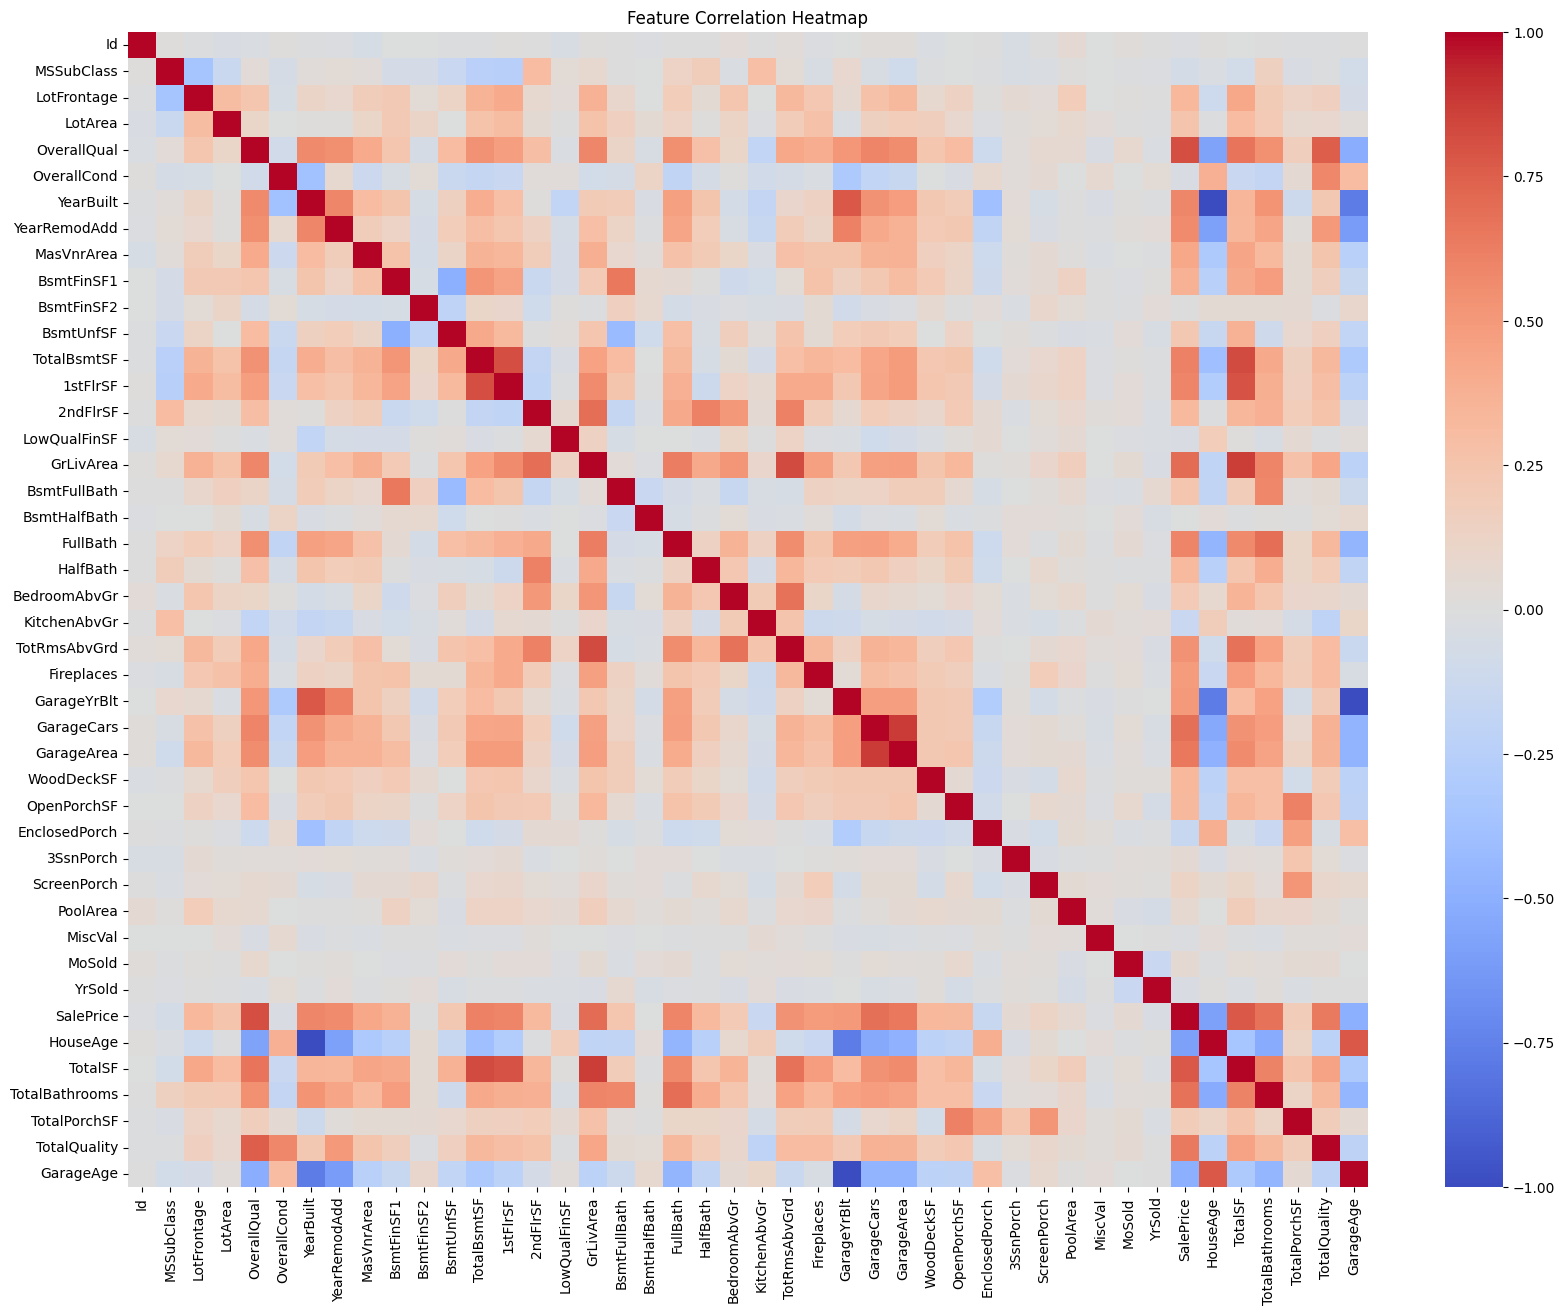

In [65]:
# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# 🎯 Features Most Correlated with SalePrice

We now identify:
- Features strongly influencing house prices
- Important variables for prediction

Strong positive correlation indicates:
```python
Higher feature value → Higher SalePrice
```

In [66]:
# =========================================================
# TOP CORRELATED FEATURES
# =========================================================

saleprice_corr = corr_matrix["SalePrice"].sort_values(
    ascending=False
)

saleprice_corr.head(20)

SalePrice         1.000000
OverallQual       0.817185
TotalSF           0.777297
GrLivArea         0.700927
GarageCars        0.680625
TotalBathrooms    0.673011
GarageArea        0.650888
TotalQuality      0.643117
TotalBsmtSF       0.612134
1stFlrSF          0.596981
FullBath          0.594771
YearBuilt         0.586570
YearRemodAdd      0.565608
TotRmsAbvGrd      0.534422
GarageYrBlt       0.495794
Fireplaces        0.489450
MasVnrArea        0.426776
BsmtFinSF1        0.372023
LotFrontage       0.335292
WoodDeckSF        0.334135
Name: SalePrice, dtype: float64

# 📊 Scatter Plot Analysis

Scatter plots help visualize:
- Linear relationships
- Outliers
- Feature trends

We now analyze:
- OverallQual vs SalePrice
- GrLivArea vs SalePrice
- TotalSF vs SalePrice

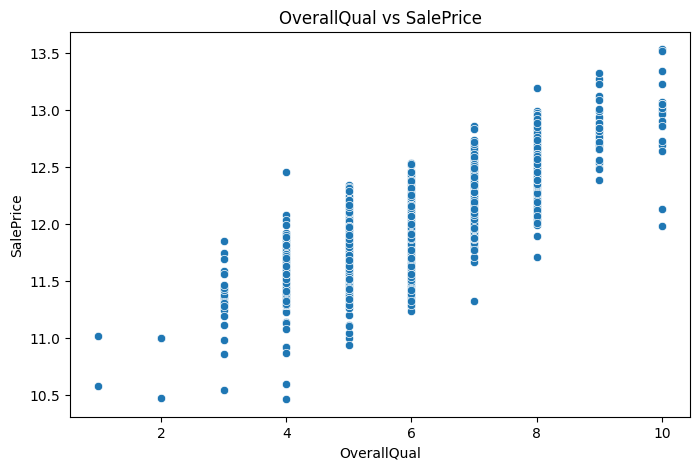

In [67]:
# =========================================================
# OVERALL QUALITY VS SALE PRICE
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train_df["OverallQual"],
    y=train_df["SalePrice"]
)

plt.title("OverallQual vs SalePrice")

plt.show()

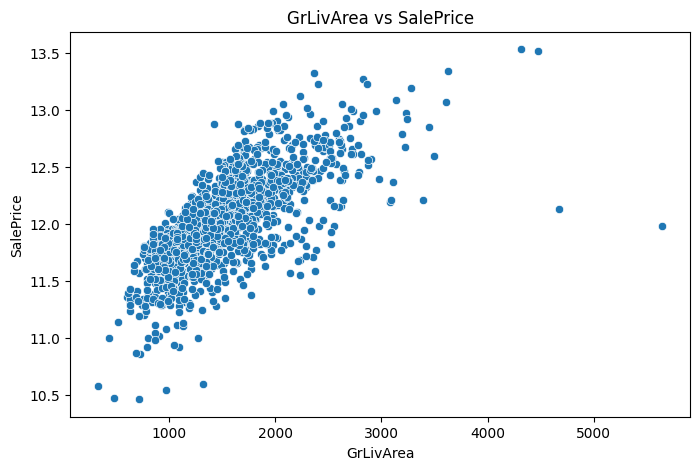

In [68]:
# =========================================================
# GROUND LIVING AREA VS SALE PRICE
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train_df["GrLivArea"],
    y=train_df["SalePrice"]
)

plt.title("GrLivArea vs SalePrice")

plt.show()

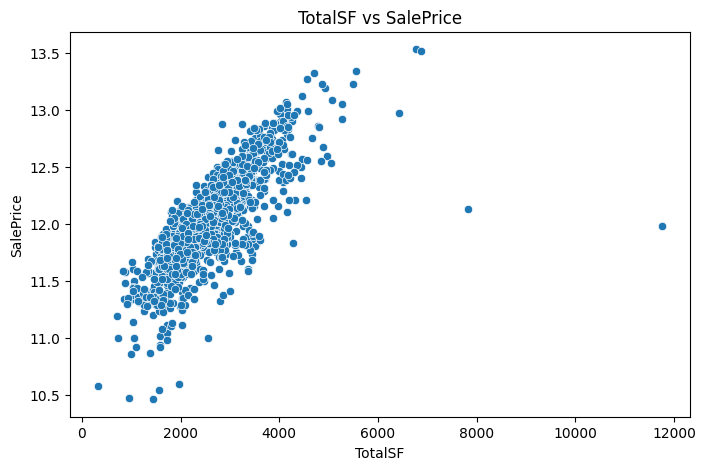

In [69]:
# =========================================================
# TOTAL SQUARE FOOTAGE VS SALE PRICE
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train_df["TotalSF"],
    y=train_df["SalePrice"]
)

plt.title("TotalSF vs SalePrice")

plt.show()

# 🚨 Outlier Detection

Outliers are extreme values that can negatively affect:
- Regression models
- RMSE score
- Prediction stability

We now detect outliers using boxplots.

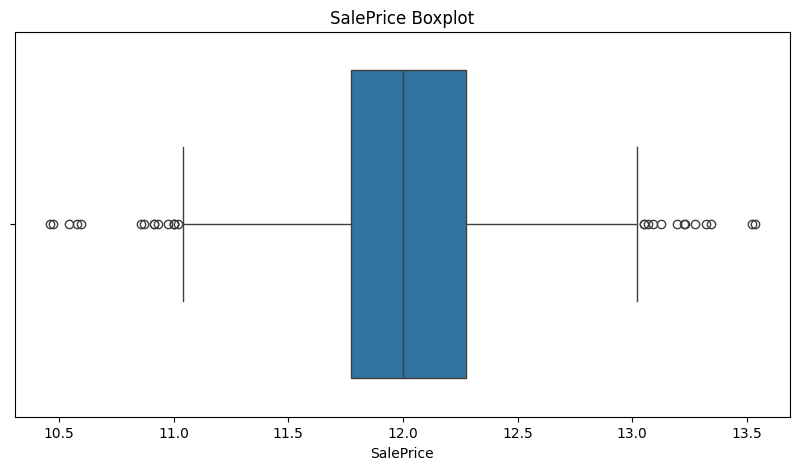

In [71]:
# =========================================================
# SALE PRICE BOXPLOT
# =========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["SalePrice"]
)

plt.title("SalePrice Boxplot")

plt.show()

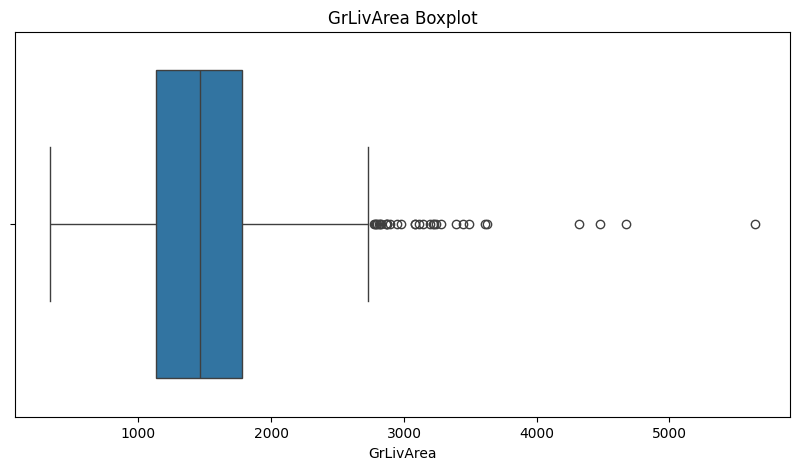

In [72]:
# =========================================================
# GROUND LIVING AREA BOXPLOT
# =========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["GrLivArea"]
)

plt.title("GrLivArea Boxplot")

plt.show()

# 📌 Observation

From boxplots and scatter plots:
- Some houses contain extremely large living areas
- Some houses have unusually high prices
- These values may act as outliers

Outlier handling can improve:
```python
RMSE Score
```

However, careful removal is important because:
- Real-world expensive houses are valid data
- Removing too many points may reduce model generalization

# 📉 Pairplot Analysis

Pairplots help visualize:
- Relationships between important variables
- Distribution patterns
- Correlation trends

We select top important features for visualization.

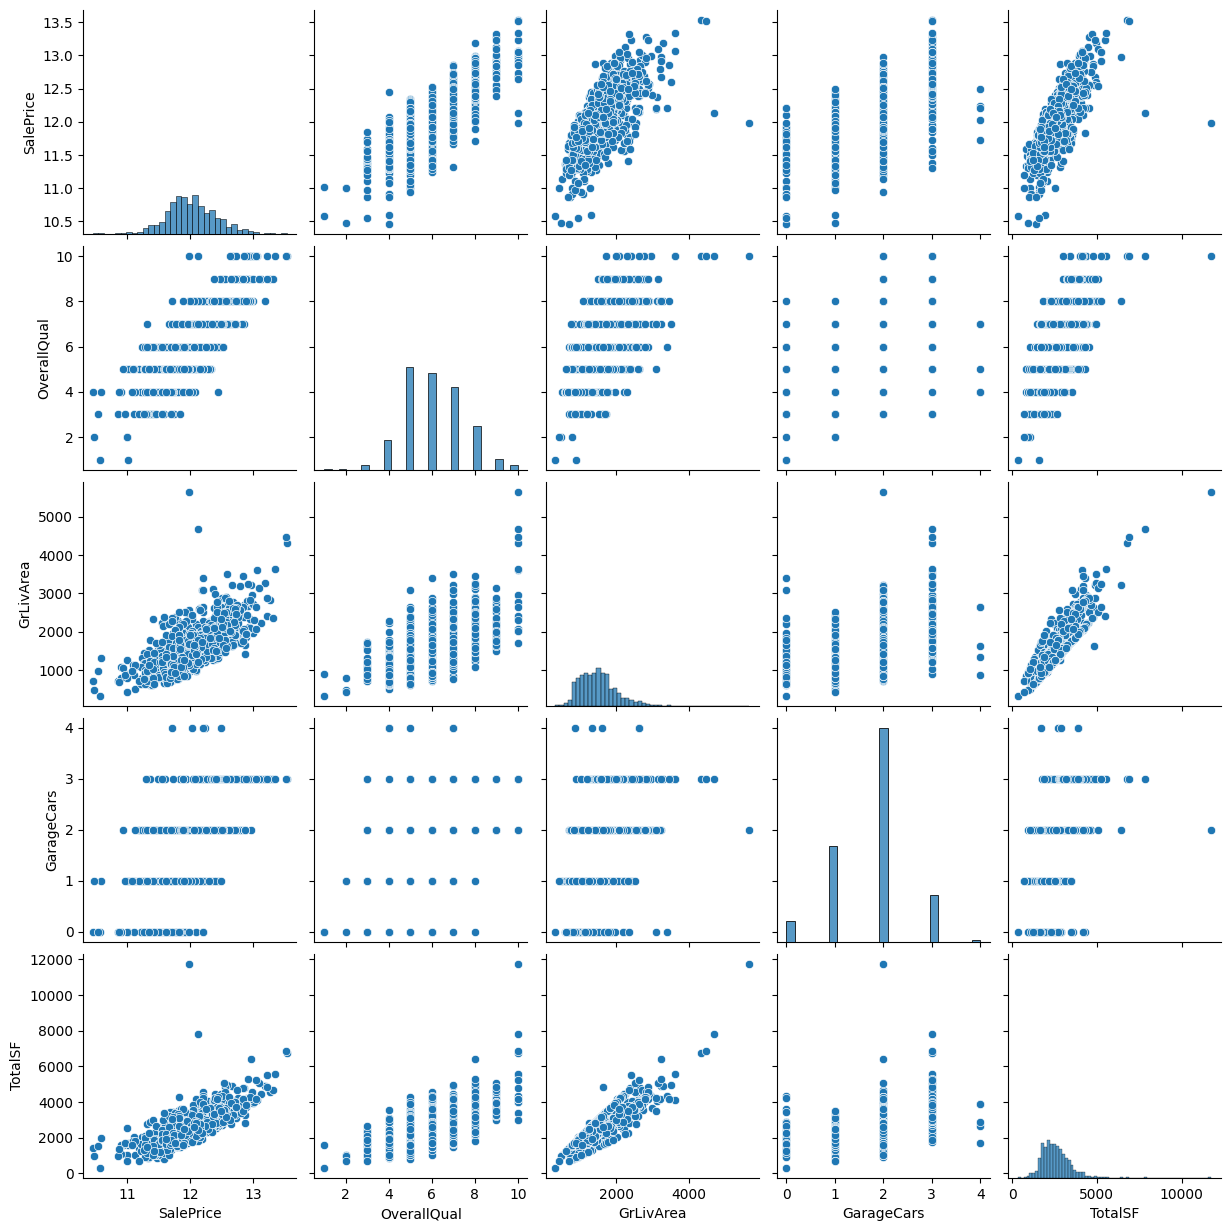

In [73]:
# =========================================================
# PAIRPLOT
# =========================================================

important_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalSF"
]

sns.pairplot(
    train_df[important_features]
)

plt.show()

# ✅ Correlation Analysis Completed

We successfully analyzed:
- Feature relationships
- Important predictors
- Correlation patterns
- Outliers
- Data distributions

The dataset is now ready for:
1. Feature Encoding
2. Train-Test Split
3. Machine Learning Model Training
4. XGBoost Regression
5. Kaggle Submission

# ⚙️ Feature Engineering

Feature engineering is one of the most important steps in machine learning.

The objective is to create new meaningful features from existing data.

Good feature engineering helps:
- Improve prediction accuracy
- Capture hidden relationships
- Improve RMSE score
- Increase model performance

In Kaggle competitions,
feature engineering often provides better improvement than changing algorithms.

# 🏠 House Age Feature

Older houses may have lower prices compared to newer houses.

We create:
```python
HouseAge
```

Formula:
```
Current Year - YearBuilt
```

This feature helps the model understand:
- Property age
- Construction recency
- Building depreciation

In [74]:
# =========================================================
# HOUSE AGE
# =========================================================

train_df["HouseAge"] = (
    2026 - train_df["YearBuilt"]
)

test_df["HouseAge"] = (
    2026 - test_df["YearBuilt"]
)

# 🛠 Remodel Age Feature

Houses renovated recently may have higher market value.

We create:
```python
RemodelAge
```

Formula:
```
Current Year - YearRemodAdd
```

In [75]:
# =========================================================
# REMODEL AGE
# =========================================================

train_df["RemodelAge"] = (
    2026 - train_df["YearRemodAdd"]
)

test_df["RemodelAge"] = (
    2026 - test_df["YearRemodAdd"]
)

# 📐 Total Square Footage

Total house size strongly affects:
```python
SalePrice
```

We combine:
- Basement area
- First floor area
- Second floor area

to create:
```python
TotalSF
```

In [76]:
# =========================================================
# TOTAL SQUARE FOOTAGE
# =========================================================

train_df["TotalSF"] = (
    train_df["TotalBsmtSF"] +
    train_df["1stFlrSF"] +
    train_df["2ndFlrSF"]
)

test_df["TotalSF"] = (
    test_df["TotalBsmtSF"] +
    test_df["1stFlrSF"] +
    test_df["2ndFlrSF"]
)

# 🚿 Total Bathrooms

Bathroom count significantly influences house prices.

We create:
```python
TotalBathrooms
```

Half bathrooms contribute:
```python
0.5
```

Formula:
```
FullBath
+ 0.5 × HalfBath
+ BsmtFullBath
+ 0.5 × BsmtHalfBath
```

In [77]:
# =========================================================
# TOTAL BATHROOMS
# =========================================================

train_df["TotalBathrooms"] = (
    train_df["FullBath"] +
    (0.5 * train_df["HalfBath"]) +
    train_df["BsmtFullBath"] +
    (0.5 * train_df["BsmtHalfBath"])
)

test_df["TotalBathrooms"] = (
    test_df["FullBath"] +
    (0.5 * test_df["HalfBath"]) +
    test_df["BsmtFullBath"] +
    (0.5 * test_df["BsmtHalfBath"])
)

# 🚗 Garage Age Feature

Garage condition and construction year influence:
- Property quality
- Home value

We create:
```python
GarageAge
```

Formula:
```
Current Year - GarageYrBlt
```

In [78]:
# =========================================================
# GARAGE AGE
# =========================================================

train_df["GarageAge"] = (
    2026 - train_df["GarageYrBlt"]
)

test_df["GarageAge"] = (
    2026 - test_df["GarageYrBlt"]
)

# 🌳 Total Porch Area

Outdoor living space affects:
- Home aesthetics
- Lifestyle value
- Property desirability

We combine:
- Open porch
- Enclosed porch
- Screen porch
- Three-season porch

to create:
```python
TotalPorchSF
```

In [79]:
# =========================================================
# TOTAL PORCH AREA
# =========================================================

train_df["TotalPorchSF"] = (
    train_df["OpenPorchSF"] +
    train_df["EnclosedPorch"] +
    train_df["3SsnPorch"] +
    train_df["ScreenPorch"]
)

test_df["TotalPorchSF"] = (
    test_df["OpenPorchSF"] +
    test_df["EnclosedPorch"] +
    test_df["3SsnPorch"] +
    test_df["ScreenPorch"]
)

# ⭐ Total Quality Feature

House quality and condition together strongly influence:
```python
SalePrice
```

We combine:
- OverallQual
- OverallCond

to create:
```python
TotalQuality
```

In [80]:
# =========================================================
# TOTAL QUALITY
# =========================================================

train_df["TotalQuality"] = (
    train_df["OverallQual"] +
    train_df["OverallCond"]
)

test_df["TotalQuality"] = (
    test_df["OverallQual"] +
    test_df["OverallCond"]
)

# 🏡 Total Home Area

We create a larger combined feature representing:
- Living area
- Basement area
- Garage area

This captures overall usable property space.

In [81]:
# =========================================================
# TOTAL HOME AREA
# =========================================================

train_df["TotalHomeArea"] = (
    train_df["GrLivArea"] +
    train_df["TotalBsmtSF"] +
    train_df["GarageArea"]
)

test_df["TotalHomeArea"] = (
    test_df["GrLivArea"] +
    test_df["TotalBsmtSF"] +
    test_df["GarageArea"]
)

# 📊 Analyze Engineered Features

We now analyze the relationship between engineered features and:
```python
SalePrice
```

This helps verify:
- Feature usefulness
- Correlation strength
- Predictive importance

In [82]:
# =========================================================
# ENGINEERED FEATURE CORRELATION
# =========================================================

engineered_features = [
    "HouseAge",
    "RemodelAge",
    "TotalSF",
    "TotalBathrooms",
    "GarageAge",
    "TotalPorchSF",
    "TotalQuality",
    "TotalHomeArea",
    "SalePrice"
]

train_df[engineered_features].corr()["SalePrice"].sort_values(
    ascending=False
)

SalePrice         1.000000
TotalHomeArea     0.808760
TotalSF           0.777297
TotalBathrooms    0.673011
TotalQuality      0.643117
TotalPorchSF      0.195167
GarageAge        -0.495794
RemodelAge       -0.565608
HouseAge         -0.586570
Name: SalePrice, dtype: float64

# 🔥 Heatmap of Engineered Features

We visualize the correlation between engineered features using a heatmap.

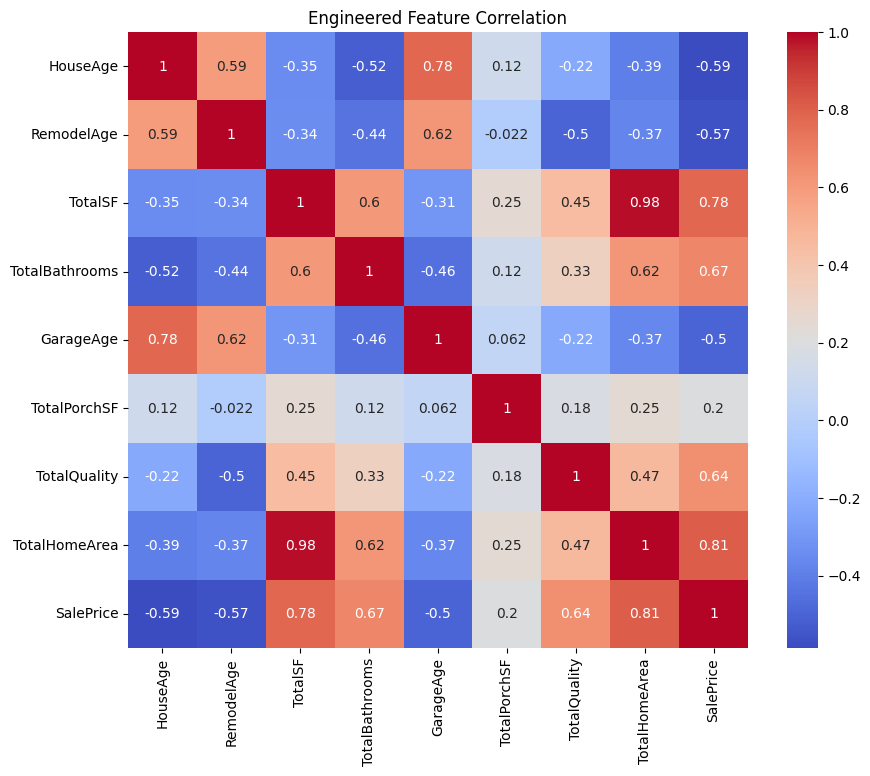

In [83]:
# =========================================================
# ENGINEERED FEATURE HEATMAP
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[engineered_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Engineered Feature Correlation")

plt.show()

# ✅ Feature Engineering Completed

We successfully created new features that improve:
- Predictive power
- Feature relationships
- Regression performance

The dataset is now ready for:
1. Encoding categorical variables
2. Train-test split
3. Machine learning model training
4. XGBoost regression
5. Kaggle submission